In [2]:

# LOAD DATASET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fashion_sales = pd.read_csv("fashion_sales.csv")

print("Dataset loaded successfully!")
print("Shape:", fashion_sales.shape)

fashion_sales.head()

Dataset loaded successfully!
Shape: (4605, 25)


,order_id,user_id,order_date,order_status,total_amount,name,email,gender,city,signup_date,...,product_name,category,brand,price,product_rating,review_rating,review_text,order_month,price_range,product_type
0,O00000004,U008986,2025-10-04 20:35:22,cancelled,689.50,Kurt Howard,nancy40@example.org,Female,New Barbarafurt,2024-12-04,...,Nimbus When,Clothing,Nimbus,67.54,3.58,NaN,NaN,2025-10,Mid Range ($50-$200),Jeans
1,O00000006,U003449,2024-10-13 09:02:27,completed,2258.34,Mason Owens,wharris@example.org,Other,Danielfort,2025-05-17,...,Harbor Night,Clothing,Harbor,209.10,3.68,NaN,NaN,2024-10,Premium ($200-$500),Skirt
2,O00000009,U000610,2025-10-29 07:00:11,cancelled,229.02,Rachel Taylor,parkerrichard@example.org,Male,Howardmouth,2025-05-15,...,Astra Without,Clothing,Astra,114.51,2.87,NaN,NaN,2025-10,Mid Range ($50-$200),Dress
3,O00000011,U004470,2025-08-14 09:59:55,shipped,1016.61,Morgan Lopez,michael10@example.com,Other,South Peggy,2025-10-14,...,Orion Most,Clothing,Orion,151.39,3.99,NaN,NaN,2025-08,Mid Range ($50-$200),Jacket
4,O00000012,U009480,2025-08-27 09:57:49,cancelled,600.23,Gabrielle Serrano,rachelblackwell@example.net,Other,New Timothy,2025-01-31,...,Nimbus Sit,Clothing,Nimbus,37.65,4.54,NaN,NaN,2025-08,Budget ($0-$50),T-Shirt


In [3]:
print(fashion_sales.columns.tolist())

['order_id', 'user_id', 'order_date', 'order_status', 'total_amount', 'name', 'email', 'gender', 'city', 'signup_date', 'order_item_id', 'product_id', 'quantity', 'item_price', 'item_total', 'product_name', 'category', 'brand', 'price', 'product_rating', 'review_rating', 'review_text', 'order_month', 'price_range', 'product_type']


### STEP 1 — Review Data Exploration

Customer review text is used to understand customer opinions about fashion products. Before applying NLP and Transformer models, the review data is examined for missing values and available product reviews.

In [4]:

print("Total rows:", len(fashion_sales))

print("\nMissing review text:")
print(fashion_sales["review_text"].isnull().sum())

print("\nMissing review ratings:")
print(fashion_sales["review_rating"].isnull().sum())

print("\nNumber of products with reviews:")
print(
    fashion_sales.loc[
        fashion_sales["review_text"].notna(),
        "product_id"
    ].nunique()
)

print("\nSample reviews:")
display(
    fashion_sales[
        [
            "product_id",
            "product_type",
            "review_text",
            "review_rating"
        ]
    ].dropna(subset=["review_text"]).head()
)

Total rows: 4605

Missing review text:
2994

Missing review ratings:
2994

Number of products with reviews:
213

Sample reviews:


,product_id,product_type,review_text,review_rating
7,P000494,Sweater,Decent product for the price.,3.0
10,P000304,T-Shirt,Highly recommend this brand.,3.0
14,P000748,T-Shirt,Color was different from images.,2.0
22,P001080,Shirt,Fast shipping and good packaging.,3.0
26,P000826,T-Shirt,Item arrived damaged.,3.0


### Create an NLP Review Dataset
A separate review dataset is created by selecting the product identifier and customer review text. Rows without review text are removed because NLP analysis requires textual input.

In [5]:

review_data = fashion_sales[
    [
        "product_id",
        "brand",
        "product_type",
        "review_text",
        "review_rating",
        "product_rating"
    ]
].copy()

# Remove rows without review text
review_data = review_data.dropna(
    subset=["review_text"]
).reset_index(drop=True)

print("Review dataset shape:", review_data.shape)

review_data.head()

Review dataset shape: (1611, 6)


,product_id,brand,product_type,review_text,review_rating,product_rating
0,P000494,Astra,Sweater,Decent product for the price.,3.0,3.65
1,P000304,Willow,T-Shirt,Highly recommend this brand.,3.0,2.68
2,P000748,Willow,T-Shirt,Color was different from images.,2.0,2.86
3,P001080,Acme,Shirt,Fast shipping and good packaging.,3.0,4.63
4,P000826,Acme,T-Shirt,Item arrived damaged.,3.0,4.38


### Basic Text Cleaning

Basic preprocessing is performed to remove missing values, convert review text into string format, and remove unnecessary spaces. This prepares the text for Transformer-based sentiment analysis.

In [6]:

review_data["review_text"] = (
    review_data["review_text"]
    .astype(str)
    .str.strip()
)

# Remove empty reviews
review_data = review_data[
    review_data["review_text"].str.len() > 0
].reset_index(drop=True)

print("Cleaned review dataset shape:", review_data.shape)

display(
    review_data[
        [
            "product_id",
            "review_text"
        ]
    ].head()
)

Cleaned review dataset shape: (1611, 6)


,product_id,review_text
0,P000494,Decent product for the price.
1,P000304,Highly recommend this brand.
2,P000748,Color was different from images.
3,P001080,Fast shipping and good packaging.
4,P000826,Item arrived damaged.


### Review Text Inspection

Sample customer reviews are examined to understand the type of textual information available in the dataset. The reviews will later be processed using a pre-trained Transformer model to identify customer sentiment.

In [7]:

for i, review in enumerate(
    review_data["review_text"].head(10),
    start=1
):
    print(f"Review {i}:")
    print(review)
    print("-" * 80)

Review 1:
Decent product for the price.
--------------------------------------------------------------------------------
Review 2:
Highly recommend this brand.
--------------------------------------------------------------------------------
Review 3:
Color was different from images.
--------------------------------------------------------------------------------
Review 4:
Fast shipping and good packaging.
--------------------------------------------------------------------------------
Review 5:
Item arrived damaged.
--------------------------------------------------------------------------------
Review 6:
Item arrived damaged.
--------------------------------------------------------------------------------
Review 7:
Not as expected, quality is poor.
--------------------------------------------------------------------------------
Review 8:
Not as expected, quality is poor.
--------------------------------------------------------------------------------
Review 9:
Decent product for the p

### Install Transformer Libraries

The Hugging Face Transformers library is used to access a pre-trained language model. Instead of training a Transformer from scratch, transfer learning is used by applying an existing model that has already learned language patterns from large amounts of text.

In [9]:
%pip install transformers torch


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Load a Pre-Trained Sentiment Analysis Transformer

A pre-trained DistilBERT Transformer model is used for sentiment analysis. The model processes customer review text and predicts whether the sentiment expressed in the review is positive or negative.

In [10]:

from transformers import pipeline

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Transformer sentiment model loaded successfully.")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Transformer sentiment model loaded successfully.


### Test Transformer Sentiment Analysis

Before applying the Transformer model to all customer reviews, sample reviews are analyzed to verify that the sentiment classification pipeline is functioning correctly.

In [11]:


sample_reviews = [
    "This product is excellent and the quality is amazing.",
    "The material is very poor and I am disappointed.",
    "I really like the product and would buy it again."
]

sentiment_analyzer(sample_reviews)

[{'label': 'POSITIVE', 'score': 0.9998875856399536},
 {'label': 'NEGATIVE', 'score': 0.9997928738594055},
 {'label': 'POSITIVE', 'score': 0.9990930557250977}]

### Transformer-Based Sentiment Analysis

The pre-trained Transformer model is applied to customer review text. Each review receives a predicted sentiment label and a confidence score. The sentiment label represents the model's interpretation of the customer's opinion.

In [12]:

sentiment_results = sentiment_analyzer(
    review_data["review_text"].tolist(),
    batch_size=16,
    truncation=True,
    max_length=512
)

print("Total reviews analyzed:", len(sentiment_results))

Total reviews analyzed: 1611


In [13]:
sentiment_results[:5]

[{'label': 'POSITIVE', 'score': 0.9998249411582947},
 {'label': 'POSITIVE', 'score': 0.9998738765716553},
 {'label': 'POSITIVE', 'score': 0.9944856762886047},
 {'label': 'POSITIVE', 'score': 0.9998019337654114},
 {'label': 'NEGATIVE', 'score': 0.9992256164550781}]

### Add Sentiment Labels to Review Data

The predicted sentiment labels and confidence scores are added to the review dataset. This creates new features that can be used to analyze customer satisfaction and improve product recommendations.

In [14]:

review_data["sentiment"] = [
    result["label"]
    for result in sentiment_results
]

review_data["sentiment_confidence"] = [
    result["score"]
    for result in sentiment_results
]

review_data.head()

,product_id,brand,product_type,review_text,review_rating,product_rating,sentiment,sentiment_confidence
0,P000494,Astra,Sweater,Decent product for the price.,3.0,3.65,POSITIVE,0.999825
1,P000304,Willow,T-Shirt,Highly recommend this brand.,3.0,2.68,POSITIVE,0.999874
2,P000748,Willow,T-Shirt,Color was different from images.,2.0,2.86,POSITIVE,0.994486
3,P001080,Acme,Shirt,Fast shipping and good packaging.,3.0,4.63,POSITIVE,0.999802
4,P000826,Acme,T-Shirt,Item arrived damaged.,3.0,4.38,NEGATIVE,0.999226


### Analyze Customer Sentiment Distribution

The distribution of positive and negative sentiments is analyzed to understand the overall customer opinion represented in the product reviews.

In [15]:

sentiment_counts = review_data[
    "sentiment"
].value_counts()

print(sentiment_counts)

sentiment
POSITIVE    1265
NEGATIVE     346
Name: count, dtype: int64


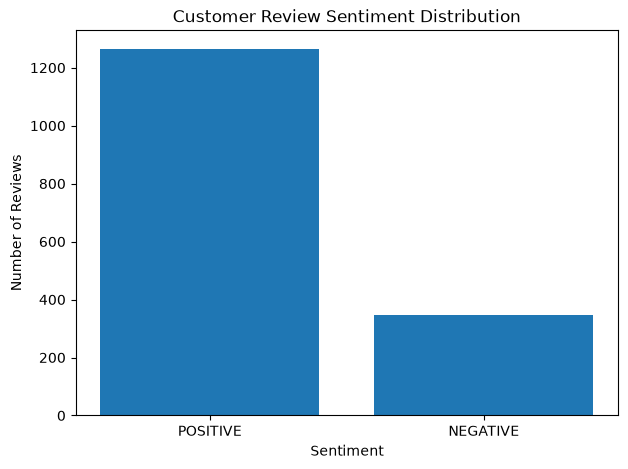

In [16]:
plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.title("Customer Review Sentiment Distribution")

plt.show()

### Customer Sentiment by Product Type

Customer sentiment is compared across different fashion product types to identify which types of products receive more positive or negative customer feedback.

In [17]:

sentiment_by_product_type = pd.crosstab(
    review_data["product_type"],
    review_data["sentiment"]
)

sentiment_by_product_type

sentiment,NEGATIVE,POSITIVE
product_type,,
Dress,25,122
Hoodie,43,134
Jacket,24,128
Jeans,50,192
Shirt,52,185
Shorts,26,47
Skirt,17,57
Sweater,25,105
T-Shirt,74,251


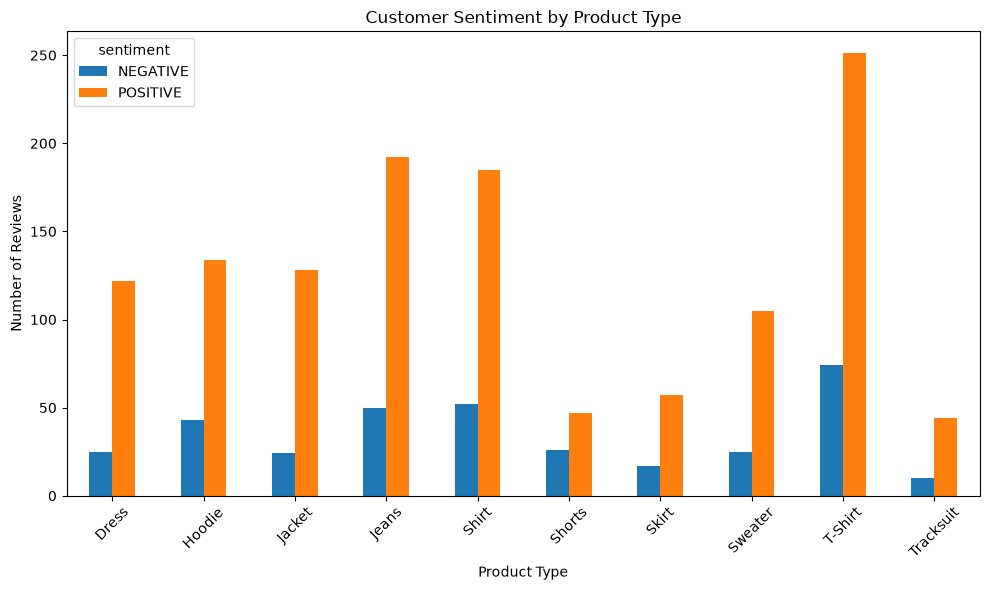

In [18]:
sentiment_by_product_type.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Product Type")
plt.ylabel("Number of Reviews")

plt.title("Customer Sentiment by Product Type")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Customer Sentiment by Brand

Sentiment analysis is also performed at the brand level to identify differences in customer opinions across fashion brands.

In [19]:

sentiment_by_brand = pd.crosstab(
    review_data["brand"],
    review_data["sentiment"]
)

sentiment_by_brand

sentiment,NEGATIVE,POSITIVE
brand,,
Acme,19,91
Astra,24,73
Everest,41,138
GreenLeaf,33,150
Harbor,51,165
NeoTech,28,126
Nimbus,8,41
Orion,33,137
Pulse,13,59


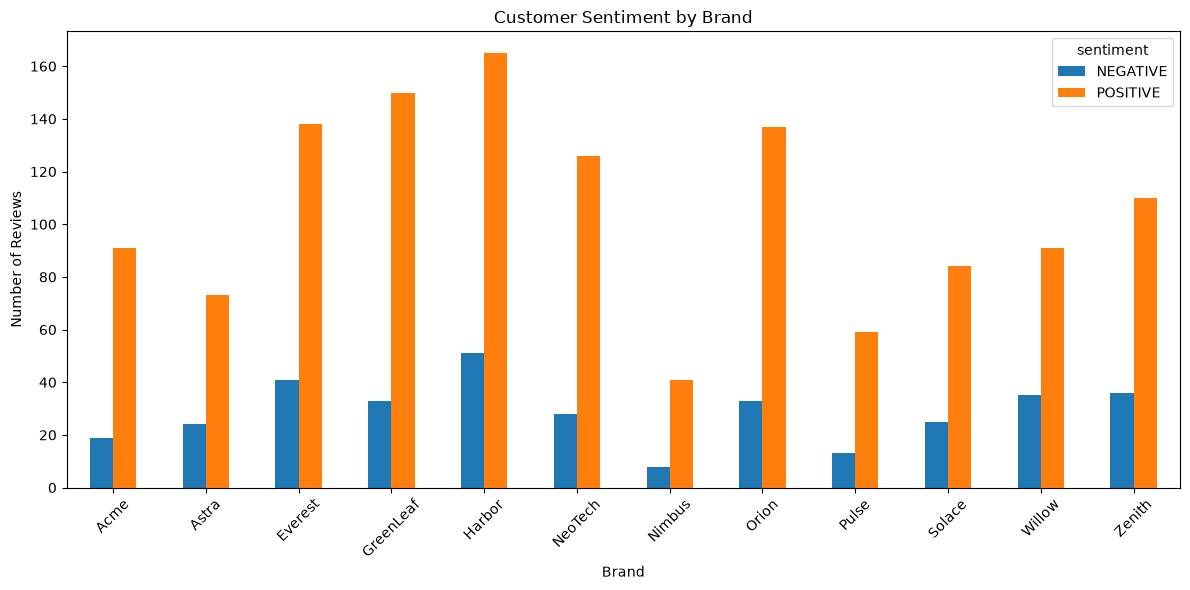

In [20]:
sentiment_by_brand.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Brand")
plt.ylabel("Number of Reviews")

plt.title("Customer Sentiment by Brand")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Create Product-Level Sentiment Features

Because a product can receive multiple customer reviews, individual review sentiments are aggregated at the product level. This creates a product sentiment score representing the overall customer opinion for each fashion product.

In [21]:

review_data["sentiment_value"] = np.where(
    review_data["sentiment"] == "POSITIVE",
    review_data["sentiment_confidence"],
    -review_data["sentiment_confidence"]
)

review_data.head()

,product_id,brand,product_type,review_text,review_rating,product_rating,sentiment,sentiment_confidence,sentiment_value
0,P000494,Astra,Sweater,Decent product for the price.,3.0,3.65,POSITIVE,0.999825,0.999825
1,P000304,Willow,T-Shirt,Highly recommend this brand.,3.0,2.68,POSITIVE,0.999874,0.999874
2,P000748,Willow,T-Shirt,Color was different from images.,2.0,2.86,POSITIVE,0.994486,0.994486
3,P001080,Acme,Shirt,Fast shipping and good packaging.,3.0,4.63,POSITIVE,0.999802,0.999802
4,P000826,Acme,T-Shirt,Item arrived damaged.,3.0,4.38,NEGATIVE,0.999226,-0.999226


In [22]:
# ==========================================
# PRODUCT-LEVEL SENTIMENT SUMMARY
# ==========================================

product_sentiment = review_data.groupby(
    "product_id"
).agg(
    average_sentiment_score=(
        "sentiment_value",
        "mean"
    ),
    
    positive_review_percentage=(
        "sentiment",
        lambda x: (x == "POSITIVE").mean() * 100
    ),
    
    total_reviews=(
        "review_text",
        "count"
    )
).reset_index()

product_sentiment.head()

,product_id,average_sentiment_score,positive_review_percentage,total_reviews
0,P000001,0.198992,60.000000,5
1,P000008,0.554727,77.777778,9
2,P000022,0.665417,83.333333,6
3,P000030,0.713090,85.714286,7
4,P000032,0.554444,77.777778,9


# Add NLP Results to Your Product Dataset
### Integrate Sentiment Analysis with Product Data



The sentiment analysis results are aggregated at the product level and merged with the product dataset. This allows customer review sentiment to be incorporated into the fashion product analysis and recommendation system. Combining structured product features with unstructured customer review information helps create a more comprehensive AI-based product recommendation approach.

In [27]:
import pandas as pd

fashion_sales = pd.read_csv("fashion_sales.csv")

print(fashion_sales.shape)
fashion_sales.head()

(4605, 25)


,order_id,user_id,order_date,order_status,total_amount,name,email,gender,city,signup_date,...,product_name,category,brand,price,product_rating,review_rating,review_text,order_month,price_range,product_type
0,O00000004,U008986,2025-10-04 20:35:22,cancelled,689.50,Kurt Howard,nancy40@example.org,Female,New Barbarafurt,2024-12-04,...,Nimbus When,Clothing,Nimbus,67.54,3.58,NaN,NaN,2025-10,Mid Range ($50-$200),Jeans
1,O00000006,U003449,2024-10-13 09:02:27,completed,2258.34,Mason Owens,wharris@example.org,Other,Danielfort,2025-05-17,...,Harbor Night,Clothing,Harbor,209.10,3.68,NaN,NaN,2024-10,Premium ($200-$500),Skirt
2,O00000009,U000610,2025-10-29 07:00:11,cancelled,229.02,Rachel Taylor,parkerrichard@example.org,Male,Howardmouth,2025-05-15,...,Astra Without,Clothing,Astra,114.51,2.87,NaN,NaN,2025-10,Mid Range ($50-$200),Dress
3,O00000011,U004470,2025-08-14 09:59:55,shipped,1016.61,Morgan Lopez,michael10@example.com,Other,South Peggy,2025-10-14,...,Orion Most,Clothing,Orion,151.39,3.99,NaN,NaN,2025-08,Mid Range ($50-$200),Jacket
4,O00000012,U009480,2025-08-27 09:57:49,cancelled,600.23,Gabrielle Serrano,rachelblackwell@example.net,Other,New Timothy,2025-01-31,...,Nimbus Sit,Clothing,Nimbus,37.65,4.54,NaN,NaN,2025-08,Budget ($0-$50),T-Shirt


In [28]:

# CREATE PRODUCT-LEVEL DATASET


product_data = (
    fashion_sales[
        [
            "product_id",
            "brand",
            "product_type",
            "price_range",
            "item_price",
            "product_rating"
        ]
    ]
    .drop_duplicates(subset="product_id")
    .reset_index(drop=True)
)

print("Product dataset shape:", product_data.shape)

product_data.head()

Product dataset shape: (213, 6)


,product_id,brand,product_type,price_range,item_price,product_rating
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54


In [29]:
print(product_sentiment.head())
print(product_sentiment.columns.tolist())

  product_id  average_sentiment_score  positive_review_percentage  \
0    P000001                 0.198992                   60.000000   
1    P000008                 0.554727                   77.777778   
2    P000022                 0.665417                   83.333333   
3    P000030                 0.713090                   85.714286   
4    P000032                 0.554444                   77.777778   

   total_reviews  
0              5  
1              9  
2              6  
3              7  
4              9  
['product_id', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews']


In [30]:
# MERGE SENTIMENT WITH PRODUCT DATA


product_data = product_data.merge(
    product_sentiment,
    on="product_id",
    how="left"
)

print("Updated product dataset shape:", product_data.shape)

product_data.head()

Updated product dataset shape: (213, 9)


,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage,total_reviews
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,0.666669,83.333333,6
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,0.776493,88.888889,9
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,0.999847,100.000000,6
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0.498688,75.000000,8
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333,6


In [31]:
# Check your product_data
product_data.head()

,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage,total_reviews
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,0.666669,83.333333,6
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,0.776493,88.888889,9
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,0.999847,100.000000,6
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0.498688,75.000000,8
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333,6


In [32]:
product_data.columns.tolist()

['product_id',
 'brand',
 'product_type',
 'price_range',
 'item_price',
 'product_rating',
 'average_sentiment_score',
 'positive_review_percentage',
 'total_reviews']

# NLP-Enhanced Product Recommendation Features

### The Transformer-generated sentiment features are incorporated into the product recommendation system. In addition to structured product information such as brand, product type, price, and rating, customer sentiment information is included. This creates a more comprehensive recommendation system that considers both product characteristics and customer opinions.

In [33]:

recommendation_features_nlp = product_data[
    [
        "brand",
        "product_type",
        "item_price",
        "product_rating",
        "average_sentiment_score",
        "positive_review_percentage"
    ]
].copy()

recommendation_features_nlp.head()

,brand,product_type,item_price,product_rating,average_sentiment_score,positive_review_percentage
0,Nimbus,Jeans,67.54,3.58,0.666669,83.333333
1,Harbor,Skirt,209.10,3.68,0.776493,88.888889
2,Astra,Dress,114.51,2.87,0.999847,100.000000
3,Orion,Jacket,151.39,3.99,0.498688,75.000000
4,Nimbus,T-Shirt,37.65,4.54,0.665417,83.333333


In [34]:
# Check Missing Values
print(
    recommendation_features_nlp.isnull().sum()
)

brand                         0
product_type                  0
item_price                    0
product_rating                0
average_sentiment_score       0
positive_review_percentage    0
dtype: int64


Handling Missing Sentiment Values

Some products may not have customer reviews and therefore do not have Transformer-generated sentiment scores. Missing sentiment values are replaced with zero, representing the absence of available sentiment information rather than a positive or negative customer opinion.

In [36]:
recommendation_features_nlp = (
    recommendation_features_nlp.fillna({
        "average_sentiment_score": 0,
        "positive_review_percentage": 0
    })
)

In [37]:
print(
    recommendation_features_nlp.isnull().sum()
)

brand                         0
product_type                  0
item_price                    0
product_rating                0
average_sentiment_score       0
positive_review_percentage    0
dtype: int64


### Encoding Product Characteristics

The categorical variables brand and product_type are converted into numerical format using one-hot encoding. This allows the recommendation algorithm to calculate similarity between products.

In [38]:
recommendation_nlp_encoded = pd.get_dummies(
    recommendation_features_nlp,
    columns=[
        "brand",
        "product_type"
    ],
    dtype=int
)

print(
    "Encoded dataset shape:",
    recommendation_nlp_encoded.shape
)

recommendation_nlp_encoded.head()

Encoded dataset shape: (213, 26)


,item_price,product_rating,average_sentiment_score,positive_review_percentage,brand_Acme,brand_Astra,brand_Everest,brand_GreenLeaf,brand_Harbor,brand_NeoTech,...,product_type_Dress,product_type_Hoodie,product_type_Jacket,product_type_Jeans,product_type_Shirt,product_type_Shorts,product_type_Skirt,product_type_Sweater,product_type_T-Shirt,product_type_Tracksuit
0,67.54,3.58,0.666669,83.333333,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,209.10,3.68,0.776493,88.888889,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,114.51,2.87,0.999847,100.000000,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,151.39,3.99,0.498688,75.000000,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,37.65,4.54,0.665417,83.333333,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Feature Scaling

The numerical features are standardized before calculating product similarity. Scaling is important because price, rating, and sentiment scores have different numerical ranges. Standardization prevents features with larger values from having an unfair influence on similarity calculations.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler_nlp_recommendation = StandardScaler()

recommendation_nlp_scaled = (
    scaler_nlp_recommendation.fit_transform(
        recommendation_nlp_encoded
    )
)

print(
    "Recommendation matrix shape:",
    recommendation_nlp_scaled.shape
)

Recommendation matrix shape: (213, 26)


### NLP-Enhanced Product Similarity

Cosine similarity is used to calculate how similar fashion products are based on structured product characteristics and Transformer-derived customer sentiment. Products with similar brands, product types, prices, ratings, and customer sentiment patterns will receive higher similarity scores.

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity_nlp = cosine_similarity(
    recommendation_nlp_scaled
)

print(
    "Similarity matrix shape:",
    product_similarity_nlp.shape
)

Similarity matrix shape: (213, 213)


# Create the NLP-Enhanced Recommendation Function

In [43]:
def recommend_products_nlp(
    product_id,
    n_recommendations=5
):

    # Find selected product
    product_indices = product_data[
        product_data["product_id"] == product_id
    ].index

    # Check whether product exists
    if len(product_indices) == 0:
        return "Product ID not found."

    product_index = product_indices[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(
            product_similarity_nlp[
                product_index
            ]
        )
    )

    # Sort from most similar to least similar
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected product itself
    similarity_scores = similarity_scores[1:]

    # Get recommended product indices
    top_indices = [
        index
        for index, score in
        similarity_scores[:n_recommendations]
    ]

    # Return recommendations
    return product_data.iloc[top_indices][
        [
            "product_id",
            "brand",
            "product_type",
            "price_range",
            "item_price",
            "product_rating",
            "average_sentiment_score",
            "positive_review_percentage"
        ]
    ]

### Test the Improved Recommendation System

In [44]:
product_data[
    [
        "product_id",
        "brand",
        "product_type",
        "item_price",
        "product_rating",
        "average_sentiment_score"
    ]
].head(10)

,product_id,brand,product_type,item_price,product_rating,average_sentiment_score
0,P001247,Nimbus,Jeans,67.54,3.58,0.666669
1,P001002,Harbor,Skirt,209.10,3.68,0.776493
2,P001301,Astra,Dress,114.51,2.87,0.999847
3,P000162,Orion,Jacket,151.39,3.99,0.498688
4,P000022,Nimbus,T-Shirt,37.65,4.54,0.665417
5,P001370,Harbor,T-Shirt,38.92,3.94,0.712680
6,P000614,Solace,T-Shirt,135.38,3.30,0.599028
7,P000494,Astra,Sweater,148.44,3.65,0.998893
8,P001080,Acme,Dress,18.31,4.63,0.554774
9,P000304,Willow,T-Shirt,120.82,2.68,0.454417


In [45]:
recommend_products_nlp(
    "P001247",
    n_recommendations=5
)

,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage
211,P000511,Nimbus,Jeans,Budget ($0-$50),34.13,2.60,0.000208,50.000000
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333
38,P000466,Nimbus,Shirt,Mid Range ($50-$200),76.15,2.61,0.999847,100.000000
199,P001536,Nimbus,Jacket,Budget ($0-$50),37.11,3.92,0.332761,66.666667
96,P001908,Nimbus,Sweater,Mid Range ($50-$200),51.78,3.81,0.599951,80.000000


### The NLP-enhanced recommendation component successfully used a pre-trained DistilBERT Transformer model to analyze customer review text and generate sentiment-based product features. These features were integrated with product information to combine structured product characteristics with customer opinions. This demonstrates how NLP and Transformer models can enhance an AI-powered fashion recommendation system by incorporating valuable insights from unstructured customer reviews.

In [49]:
print(product_data.columns.tolist())

['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews']


In [50]:
# ==========================================
# ADD K-MEANS CLUSTER TO FINAL PRODUCT DATA
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Select features for clustering
clustering_features = product_data[
    [
        "brand",
        "product_type",
        "item_price",
        "product_rating"
    ]
].copy()

# Encode categorical variables
clustering_encoded = pd.get_dummies(
    clustering_features,
    columns=["brand", "product_type"],
    dtype=int
)

# Scale the features
scaler_kmeans = StandardScaler()

clustering_scaled = scaler_kmeans.fit_transform(
    clustering_encoded
)

# Create K-Means model with K = 6
kmeans_model = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

# Add cluster column
product_data["cluster"] = kmeans_model.fit_predict(
    clustering_scaled
)

print("✅ Cluster column added successfully!")

print("\nCluster counts:")
print(product_data["cluster"].value_counts().sort_index())

✅ Cluster column added successfully!

Cluster counts:
cluster
0    26
1    68
2    28
3    49
4    22
5    20
Name: count, dtype: int64


In [51]:
print(product_data.columns.tolist())

['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews', 'cluster']


In [52]:
product_data.head()

,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage,total_reviews,cluster
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,0.666669,83.333333,6,4
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,0.776493,88.888889,9,1
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,0.999847,100.000000,6,2
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0.498688,75.000000,8,0
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333,6,1


In [53]:
product_data.to_csv(
    "ai_enhanced_product_data.csv",
    index=False
)

print("AI-enhanced product dataset saved successfully!")

AI-enhanced product dataset saved successfully!


In [54]:
ai_product_data = pd.read_csv(
    "ai_enhanced_product_data.csv"
)

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px


# ==========================
# Page Configuration
# ==========================

st.set_page_config(
    page_title="Fashion Sales Dashboard",
    page_icon="👗",
    layout="wide"
)


# ==========================
# Dashboard Title
# ==========================

st.title("👗 AI Personalized Fashion Shopping Assistant")
st.subheader("Fashion Business Analytics Dashboard")


# ==========================
# Load Dataset
# ==========================

fashion_sales = pd.read_csv("fashion_sales.csv")

st.write(fashion_sales.columns.tolist())

fashion_sales["order_date"] = pd.to_datetime(
    fashion_sales["order_date"]
)


# ==========================
# Feature Engineering
# ==========================

# Create price range feature

fashion_sales["price_range"] = pd.cut(
    fashion_sales["price"],
    bins=[
        0,
        50,
        100,
        200,
        500,
        float("inf")
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium",
        "Luxury"
    ]
)


# ==========================
# Sidebar Filters
# ==========================

st.sidebar.header("🔍 Filter Fashion Sales")


selected_brand = st.sidebar.selectbox(
    "Select Brand",
    ["All"] + sorted(
        fashion_sales["brand"]
        .dropna()
        .unique()
    )
)


selected_gender = st.sidebar.selectbox(
    "Select Gender",
    ["All"] + sorted(
        fashion_sales["gender"]
        .dropna()
        .unique()
    )
)

selected_product_type = st.sidebar.selectbox(
    "Select Product Type",
    ["All"] + sorted(
        fashion_sales["product_type"]
        .dropna()
        .unique()
        .tolist()
    )
)


# ==========================
# Apply Filters
# ==========================

filtered_data = fashion_sales.copy()


if selected_brand != "All":

    filtered_data = filtered_data[
        filtered_data["brand"] == selected_brand
    ]


if selected_gender != "All":

    filtered_data = filtered_data[
        filtered_data["gender"] == selected_gender
    ]

if selected_product_type != "All":
    filtered_data = filtered_data[
        filtered_data["product_type"] == selected_product_type
    ]


# ==========================
# KPI Calculations
# ==========================

total_revenue = (
    filtered_data["item_total"]
    .sum()
)


total_orders = (
    filtered_data["order_id"]
    .nunique()
)


total_customers = (
    filtered_data["user_id"]
    .nunique()
)


average_order_value = (
    filtered_data
    .groupby("order_id")["item_total"]
    .sum()
    .mean()
)


average_rating = (
    filtered_data["product_rating"]
    .mean()
)



# ==========================
# KPI Display
# ==========================

st.subheader(
    "📊 Key Performance Indicators"
)


col1, col2, col3, col4, col5 = st.columns(5)


col1.metric(
    "💰 Revenue",
    f"${total_revenue:,.2f}"
)


col2.metric(
    "🛒 Orders",
    total_orders
)


col3.metric(
    "👥 Customers",
    total_customers
)


col4.metric(
    "📦 Avg Order",
    f"${average_order_value:.2f}"
)


col5.metric(
    "⭐ Rating",
    f"{average_rating:.2f}"
)



# ==========================
# Revenue by Brand
# ==========================

st.subheader(
    "📊 Revenue by Brand"
)


brand_revenue = (
    filtered_data
    .groupby("brand")["item_total"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)


fig_brand = px.bar(
    brand_revenue,
    x="brand",
    y="item_total",
    color="item_total",
    title="Revenue by Brand"
)


st.plotly_chart(
    fig_brand,
    use_container_width=True,
    key="brand_chart"
)



# ==========================
# Monthly Revenue
# ==========================

st.subheader(
    "📈 Monthly Revenue"
)


monthly_revenue = (
    filtered_data
    .groupby(
        filtered_data["order_date"]
        .dt
        .to_period("M")
    )["item_total"]
    .sum()
    .reset_index()
)


monthly_revenue["order_date"] = (
    monthly_revenue["order_date"]
    .astype(str)
)


fig_month = px.line(
    monthly_revenue,
    x="order_date",
    y="item_total",
    markers=True,
    title="Monthly Revenue Trend"
)


st.plotly_chart(
    fig_month,
    use_container_width=True,
    key="monthly_chart"
)



# ==========================
# Top Selling Products
# ==========================

st.subheader(
    "🏆 Top 10 Best Selling Products"
)


top_products = (
    filtered_data
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
    .reset_index()
)


fig_products = px.bar(
    top_products,
    x="product_name",
    y="quantity",
    color="quantity",
    title="Top 10 Selling Products"
)


st.plotly_chart(
    fig_products,
    use_container_width=True,
    key="products_chart"
)



# ==========================
# Revenue by Gender
# ==========================

st.subheader(
    "🥧 Revenue by Gender"
)


gender_revenue = (
    filtered_data
    .groupby("gender")["item_total"]
    .sum()
    .reset_index()
)


fig_gender = px.pie(
    gender_revenue,
    names="gender",
    values="item_total",
    title="Revenue by Gender"
)


st.plotly_chart(
    fig_gender,
    use_container_width=True,
    key="gender_chart"
)



# ==========================
# Product Sales by Price Range
# ==========================

st.subheader(
    "📊 Product Sales by Price Range"
)


price_range_sales = (
    filtered_data
    .groupby(
        "price_range",
        observed=False
    )["quantity"]
    .sum()
    .reset_index()
)


fig_price = px.bar(
    price_range_sales,
    x="price_range",
    y="quantity",
    color="quantity",
    title="Sales by Price Range"
)


st.plotly_chart(
    fig_price,
    use_container_width=True,
    key="price_chart"
)

# ==========================
# Customer Preferred Brands
# ==========================

st.subheader(
    "❤️ Customer Preferred Brands"
)


preferred_brands = (
    filtered_data
    .groupby("brand")["user_id"]
    .nunique()
    .sort_values(
        ascending=False
    )
    .reset_index()
)


preferred_brands.columns = [
    "Brand",
    "Customers"
]


fig_preferred_brand = px.bar(
    preferred_brands.head(10),
    x="Brand",
    y="Customers",
    color="Customers",
    title="Top Preferred Brands by Customers"
)


st.plotly_chart(
    fig_preferred_brand,
    use_container_width=True,
    key="preferred_brand_chart"
)



# ==========================
# Customer Purchase Frequency
# ==========================

st.subheader(
    "🔁 Customer Purchase Frequency"
)


purchase_frequency = (
    filtered_data
    .groupby("user_id")["order_id"]
    .nunique()
    .reset_index()
)


purchase_frequency.columns = [
    "Customer ID",
    "Number of Orders"
]


fig_frequency = px.histogram(
    purchase_frequency,
    x="Number of Orders",
    nbins=10,
    title="Customer Purchase Frequency Distribution"
)


st.plotly_chart(
    fig_frequency,
    use_container_width=True,
    key="purchase_frequency_chart"
)



# ==========================
# Top Customers by Spending
# ==========================

st.subheader(
    "🏆 Top Customers by Spending"
)


top_customers = (
    filtered_data
    .groupby("user_id")["item_total"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
    .reset_index()
)


top_customers.columns = [
    "Customer ID",
    "Total Spending"
]


fig_customer = px.bar(
    top_customers,
    x="Customer ID",
    y="Total Spending",
    color="Total Spending",
    title="Top 10 Customers by Spending"
)


st.plotly_chart(
    fig_customer,
    use_container_width=True,
    key="top_customer_chart"
)



# ==========================
# AI Product Recommendation
# ==========================

st.subheader(
    "🤖 AI Clothing Recommendation"
)


# Create product-level dataset

product_data = (
    filtered_data
    .groupby(
        [
            "product_name",
            "brand",
            "price_range"
        ],
        observed=False
    )
    .agg(
        {
            "product_rating": "mean",
            "quantity": "sum"
        }
    )
    .reset_index()
)


product_data.columns = [
    "Product",
    "Brand",
    "Price Range",
    "Rating",
    "Quantity Sold"
]




# ==========================
# Create Popularity Score
# ==========================

def popularity_score(quantity):

    if quantity >= product_data["Quantity Sold"].quantile(0.75):
        return "High"

    elif quantity >= product_data["Quantity Sold"].quantile(0.25):
        return "Medium"

    else:
        return "Low"


product_data["Popularity"] = (
    product_data["Quantity Sold"]
    .apply(popularity_score)
)




# Product selection

selected_product = st.selectbox(
    "Choose a product for recommendation",
    product_data["Product"].unique()
)



# Selected product details

selected_item = product_data[
    product_data["Product"] == selected_product
].iloc[0]



# Recommendation logic

recommendations = product_data[
    (
        product_data["Brand"]
        ==
        selected_item["Brand"]
    )
    |
    (
        product_data["Price Range"]
        ==
        selected_item["Price Range"]
    )
]



recommendations = (
    recommendations
    .sort_values(
        by="Rating",
        ascending=False
    )
    .head(10)
)



st.write(
    "Recommended products based on brand preference, price range, rating and popularity:"
)



st.dataframe(
    recommendations[
        [
            "Product",
            "Brand",
            "Price Range",
            "Rating",
            "Popularity"
        ]
    ],
    use_container_width=True
)




# ==========================
# Download Filtered Data
# ==========================

csv = filtered_data.to_csv(
    index=False
)


st.download_button(
    label="📥 Download Filtered Data",
    data=csv,
    file_name="filtered_fashion_sales.csv",
    mime="text/csv"
)



In [58]:
product_data.to_csv(
    "product_data.csv",
    index=False
)

print("product_data.csv saved successfully!")

product_data.csv saved successfully!


In [56]:
print(product_data.columns.tolist())

['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews', 'cluster']


In [59]:
product_data.head()

,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage,total_reviews,cluster
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,0.666669,83.333333,6,4
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,0.776493,88.888889,9,1
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,0.999847,100.000000,6,2
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0.498688,75.000000,8,0
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333,6,1


# Install the LLM library

In [60]:
%pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [openai] 9/10 [openai]c]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [61]:
product_data.to_csv(
    "product_data.csv",
    index=False
)

In [62]:
# verify finala dataset
print(product_data.shape)
print(product_data.columns.tolist())

product_data.head()

(213, 10)
['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews', 'cluster']


,product_id,brand,product_type,price_range,item_price,product_rating,average_sentiment_score,positive_review_percentage,total_reviews,cluster
0,P001247,Nimbus,Jeans,Mid Range ($50-$200),67.54,3.58,0.666669,83.333333,6,4
1,P001002,Harbor,Skirt,Premium ($200-$500),209.10,3.68,0.776493,88.888889,9,1
2,P001301,Astra,Dress,Mid Range ($50-$200),114.51,2.87,0.999847,100.000000,6,2
3,P000162,Orion,Jacket,Mid Range ($50-$200),151.39,3.99,0.498688,75.000000,8,0
4,P000022,Nimbus,T-Shirt,Budget ($0-$50),37.65,4.54,0.665417,83.333333,6,1


In [63]:
# where csv is saved 
import os

print(os.getcwd())
print(os.listdir())

/Users/jayanthkumar/Desktop/Ecommerce_project/jupyter_nb
['.DS_Store', 'Ecommerce_Dashboard', 'fashion_sales.csv', 'ai_enhanced_product_data.csv', 'Ecommerce_NLP.ipynb', 'product_data.csv', 'Ecommerce_EDA1.ipynb', 'sales.csv', 'Ecommerce_EDA2.ipynb', 'Ecommerce_ML.ipynb']


In [64]:
print(product_data.columns.tolist())

['product_id', 'brand', 'product_type', 'price_range', 'item_price', 'product_rating', 'average_sentiment_score', 'positive_review_percentage', 'total_reviews', 'cluster']
